<p style="margin: 5px 0 0 0; color: #666;"><em>Desarrollado con Claude - Anthropic</em></p>

# 6. Análisis Exploratorio de Datos (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## Introducción al EDA

### ¿Qué es?

El **Análisis Exploratorio de Datos** (EDA, por sus siglas en inglés) es el proceso sistemático de investigar un dataset para descubrir patrones, detectar anomalías, verificar supuestos y generar hipótesis antes de aplicar modelos predictivos o tomar decisiones. Fue formalizado por el estadístico John Tukey en 1977 y es una etapa imprescindible en cualquier proyecto de ciencia de datos.

**Etapas del EDA:**

| Etapa | Descripción | Herramientas principales |
|---|---|---|
| **Exploración inicial** | Dimensiones, tipos, faltantes, estadísticas | `info()`, `describe()`, `isnull()` |
| **Análisis univariado** | Distribución de cada variable individual | Histogramas, box plots, `value_counts()` |
| **Análisis bivariado** | Relaciones entre pares de variables | Scatter plots, correlaciones, box plots por grupo |
| **Análisis multivariado** | Interacción de múltiples variables | Heatmaps, pair plots, pivot tables |
| **Detección de patrones** | Tendencias temporales, estacionalidad | Líneas de tendencia, resample, rolling |
| **Identificación de anomalías** | Valores atípicos y datos inconsistentes | IQR, Z-score, box plots |
| **Generación de insights** | Conclusiones y recomendaciones accionables | Resúmenes, KPIs, rankings |

### ¿Para qué sirve?

El EDA sirve para:

- **Entender la naturaleza de los datos** antes de aplicar cualquier modelo o técnica avanzada
- **Descubrir patrones y relaciones** que no son evidentes a simple vista
- **Detectar problemas de calidad** como outliers, faltantes, inconsistencias y sesgos
- **Generar hipótesis** que luego pueden validarse con análisis estadístico formal
- **Guiar la selección de modelos** entendiendo la distribución y correlación de las variables
- **Comunicar hallazgos** a stakeholders con visualizaciones claras y métricas de negocio

### ¿Cómo se usa?

En las secciones siguientes, recorreremos todas las etapas del EDA con un dataset de ventas: preparación, análisis univariado y bivariado, análisis multivariado, detección de patrones y anomalías, análisis de correlaciones, generación de insights y documentación del proceso.

## 1. Preparación del Dataset

### ¿Qué es?

La **preparación del dataset** es el paso previo al análisis exploratorio: consiste en cargar o generar los datos, verificar su estructura inicial (dimensiones, tipos, primeras filas) y crear variables derivadas necesarias para el análisis. En proyectos reales, esto incluye la lectura desde archivos o bases de datos; aquí generamos un dataset sintético realista.

**Componentes del dataset de ejemplo:**

| Variable | Tipo | Descripción |
|---|---|---|
| `Fecha` | datetime | Fecha y hora de la transacción |
| `Producto` | categórica | Nombre del producto vendido |
| `Categoria` | categórica | Categoría del producto |
| `Precio` | numérica | Precio unitario del producto |
| `Cantidad` | numérica | Unidades vendidas |
| `Region` | categórica | Zona geográfica de la venta |
| `Vendedor` | categórica | Nombre del vendedor |
| `Descuento` | numérica | Porcentaje de descuento aplicado |
| `MetodoPago` | categórica | Forma de pago utilizada |
| `Ingresos` | numérica (derivada) | Precio × Cantidad × (1 − Descuento) |

### ¿Para qué sirve?

La preparación del dataset sirve para:

- **Establecer el punto de partida** del análisis con datos estructurados y listos para explorar
- **Crear variables derivadas** que enriquezcan el análisis (ingresos, componentes de fecha)
- **Verificar la integridad inicial** revisando dimensiones, tipos y primeras filas
- **Simular escenarios realistas** cuando no se dispone de datos reales para practicar

### ¿Cómo se usa?

En el código siguiente, generamos un dataset de 1,000 transacciones de ventas con variables numéricas y categóricas, creamos la columna calculada de ingresos y extraemos componentes temporales (mes, día de la semana, hora) para análisis posterior.

In [3]:
# Crear dataset de ventas
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'Fecha': pd.date_range('2023-01-01', periods=n, freq='D'),
    'Producto': np.random.choice(['Laptop', 'Mouse', 'Teclado', 'Monitor', 'Webcam', 'Auriculares'], n),
    'Categoria': np.random.choice(['Computadoras', 'Periféricos', 'Audio'], n),
    'Precio': np.random.uniform(20, 1500, n),
    'Cantidad': np.random.randint(1, 20, n),
    'Region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'], n),
    'Vendedor': np.random.choice(['Ana', 'Carlos', 'María', 'Luis', 'Pedro', 'Sofia'], n),
    'Descuento': np.random.uniform(0, 0.3, n),
    'MetodoPago': np.random.choice(['Tarjeta', 'Efectivo', 'Transferencia'], n)
})

df['Ingresos'] = df['Precio'] * df['Cantidad'] * (1 - df['Descuento'])
df['Mes'] = df['Fecha'].dt.month
df['DiaSemana'] = df['Fecha'].dt.day_name()
df['Hora'] = df['Fecha'].dt.hour

print("=" * 70)
print("DATASET DE ANÁLISIS".center(70))
print("=" * 70)
print(f"\nDimensiones: {df.shape}")
print(f"\nPrimeras filas:\n{df.head()}")
print(f"\nInformación del dataset:")
print(df.info())

                         DATASET DE ANÁLISIS                          

Dimensiones: (1000, 13)

Primeras filas:
       Fecha Producto     Categoria       Precio  Cantidad  Region Vendedor  \
0 2023-01-01  Monitor   Periféricos   262.719232        13   Oeste    Sofia   
1 2023-01-02   Webcam  Computadoras   669.138680         1     Sur     Luis   
2 2023-01-03  Teclado   Periféricos  1092.743309         8   Oeste    María   
3 2023-01-04   Webcam   Periféricos   898.052399        12    Este    Pedro   
4 2023-01-05   Webcam         Audio   982.435395        19  Centro   Carlos   

   Descuento     MetodoPago      Ingresos  Mes  DiaSemana  Hora  
0   0.092362        Tarjeta   3099.900645    1     Sunday     0  
1   0.143160       Efectivo    573.344771    1     Monday     0  
2   0.237919        Tarjeta   6662.072107    1    Tuesday     0  
3   0.294372  Transferencia   7604.285858    1  Wednesday     0  
4   0.279747       Efectivo  13444.444800    1   Thursday     0  

Información del

## 2. Análisis Univariado

### ¿Qué es?

El **análisis univariado** estudia cada variable de forma individual para entender su distribución, tendencia central, dispersión y forma. Se aplica tanto a variables numéricas (histogramas, box plots, estadísticas descriptivas) como a categóricas (frecuencias, gráficos de barras).

**Métricas y visualizaciones por tipo:**

| Tipo de variable | Métricas | Visualizaciones |
|---|---|---|
| **Numéricas** | Media, mediana, std, min, max, cuartiles | Histograma, box plot, Q-Q plot |
| **Categóricas** | Frecuencia absoluta, frecuencia relativa (%) | Gráfico de barras, pie chart |

**Medidas de forma de la distribución:**

| Medida | Descripción | Interpretación |
|---|---|---|
| **Asimetría** (Skewness) | Grado de simetría | 0 = simétrica, >0 = cola derecha, <0 = cola izquierda |
| **Curtosis** (Kurtosis) | Peso de las colas | 0 = normal, >0 = colas pesadas, <0 = colas ligeras |

### ¿Para qué sirve?

El análisis univariado sirve para:

- **Entender la distribución de cada variable** antes de buscar relaciones entre ellas
- **Detectar outliers y valores inesperados** mediante box plots y estadísticas de dispersión
- **Evaluar la normalidad** de las variables con Q-Q plots y medidas de asimetría/curtosis
- **Conocer la composición de categóricas** identificando categorías dominantes o desbalanceadas
- **Decidir transformaciones necesarias** como logaritmos para variables sesgadas
- **Establecer una línea base** de estadísticas descriptivas para referencia

### ¿Cómo se usa?

En el código siguiente, analizamos las variables numéricas (Precio, Ingresos, Cantidad, Descuento) con histogramas, box plots, Q-Q plots y medidas de forma; luego las variables categóricas (Producto, Región, Vendedor, MetodoPago) con conteos de frecuencia y gráficos de barras.

              ANÁLISIS UNIVARIADO - VARIABLES NUMÉRICAS               

1. ESTADÍSTICAS DESCRIPTIVAS
            Precio     Cantidad    Descuento      Ingresos
count  1000.000000  1000.000000  1000.000000   1000.000000
mean    744.951611    10.049000     0.149581   6376.910878
std     420.444618     5.563232     0.085590   5462.271309
min      20.278831     1.000000     0.000493     17.159326
25%     370.711116     5.000000     0.076866   2038.124682
50%     738.817120    10.000000     0.150088   4888.356172
75%    1111.169377    15.000000     0.223514   9427.602544
max    1495.675672    19.000000     0.299715  25198.301237


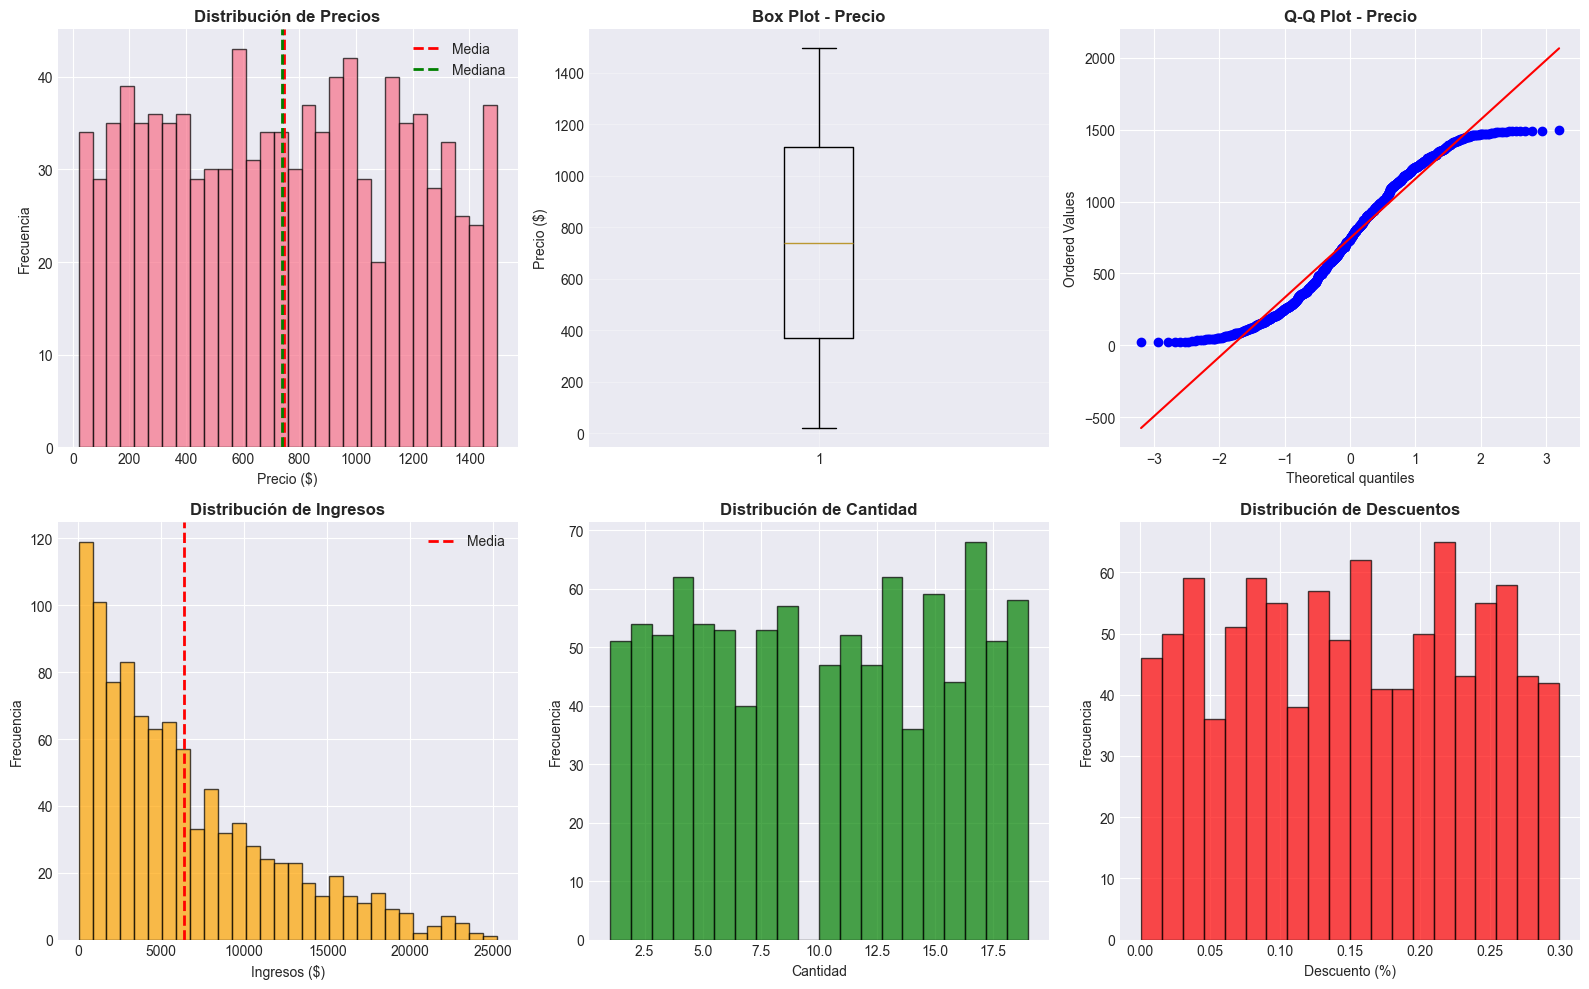


2. MEDIDAS DE FORMA
Asimetría (Skewness) - Precio: 0.034
Curtosis (Kurtosis) - Precio: -1.168

Asimetría - Ingresos: 1.060
Curtosis - Ingresos: 0.470


In [4]:
print("=" * 70)
print("ANÁLISIS UNIVARIADO - VARIABLES NUMÉRICAS".center(70))
print("=" * 70)

# Estadísticas descriptivas
print("\n1. ESTADÍSTICAS DESCRIPTIVAS")
print(df[['Precio', 'Cantidad', 'Descuento', 'Ingresos']].describe())

# Análisis de distribución
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Precio
axes[0, 0].hist(df['Precio'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['Precio'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[0, 0].axvline(df['Precio'].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
axes[0, 0].set_xlabel('Precio ($)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Precios', fontweight='bold')
axes[0, 0].legend()

# Box plot de Precio
axes[0, 1].boxplot(df['Precio'], vert=True)
axes[0, 1].set_ylabel('Precio ($)')
axes[0, 1].set_title('Box Plot - Precio', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot para normalidad
stats.probplot(df['Precio'], dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot - Precio', fontweight='bold')

# Ingresos
axes[1, 0].hist(df['Ingresos'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].axvline(df['Ingresos'].mean(), color='red', linestyle='--', linewidth=2, label='Media')
axes[1, 0].set_xlabel('Ingresos ($)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Ingresos', fontweight='bold')
axes[1, 0].legend()

# Cantidad
axes[1, 1].hist(df['Cantidad'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Cantidad')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de Cantidad', fontweight='bold')

# Descuento
axes[1, 2].hist(df['Descuento'], bins=20, edgecolor='black', alpha=0.7, color='red')
axes[1, 2].set_xlabel('Descuento (%)')
axes[1, 2].set_ylabel('Frecuencia')
axes[1, 2].set_title('Distribución de Descuentos', fontweight='bold')

plt.tight_layout()
plt.show()

# Métricas de asimetría y curtosis
print("\n2. MEDIDAS DE FORMA")
print(f"Asimetría (Skewness) - Precio: {stats.skew(df['Precio']):.3f}")
print(f"Curtosis (Kurtosis) - Precio: {stats.kurtosis(df['Precio']):.3f}")
print(f"\nAsimetría - Ingresos: {stats.skew(df['Ingresos']):.3f}")
print(f"Curtosis - Ingresos: {stats.kurtosis(df['Ingresos']):.3f}")

             ANÁLISIS UNIVARIADO - VARIABLES CATEGÓRICAS              

1. PRODUCTO
Producto
Laptop         181
Monitor        174
Webcam         172
Mouse          164
Auriculares    155
Teclado        154
Name: count, dtype: int64
Porcentaje:
Producto
Laptop         18.1
Monitor        17.4
Webcam         17.2
Mouse          16.4
Auriculares    15.5
Teclado        15.4
Name: proportion, dtype: float64

2. REGION
Region
Centro    217
Este      204
Sur       195
Oeste     194
Norte     190
Name: count, dtype: int64
Porcentaje:
Region
Centro    21.7
Este      20.4
Sur       19.5
Oeste     19.4
Norte     19.0
Name: proportion, dtype: float64

3. VENDEDOR
Vendedor
María     178
Luis      177
Sofia     167
Pedro     165
Carlos    160
Ana       153
Name: count, dtype: int64
Porcentaje:
Vendedor
María     17.8
Luis      17.7
Sofia     16.7
Pedro     16.5
Carlos    16.0
Ana       15.3
Name: proportion, dtype: float64

4. METODOPAGO
MetodoPago
Efectivo         353
Transferencia    329
Tarjeta 

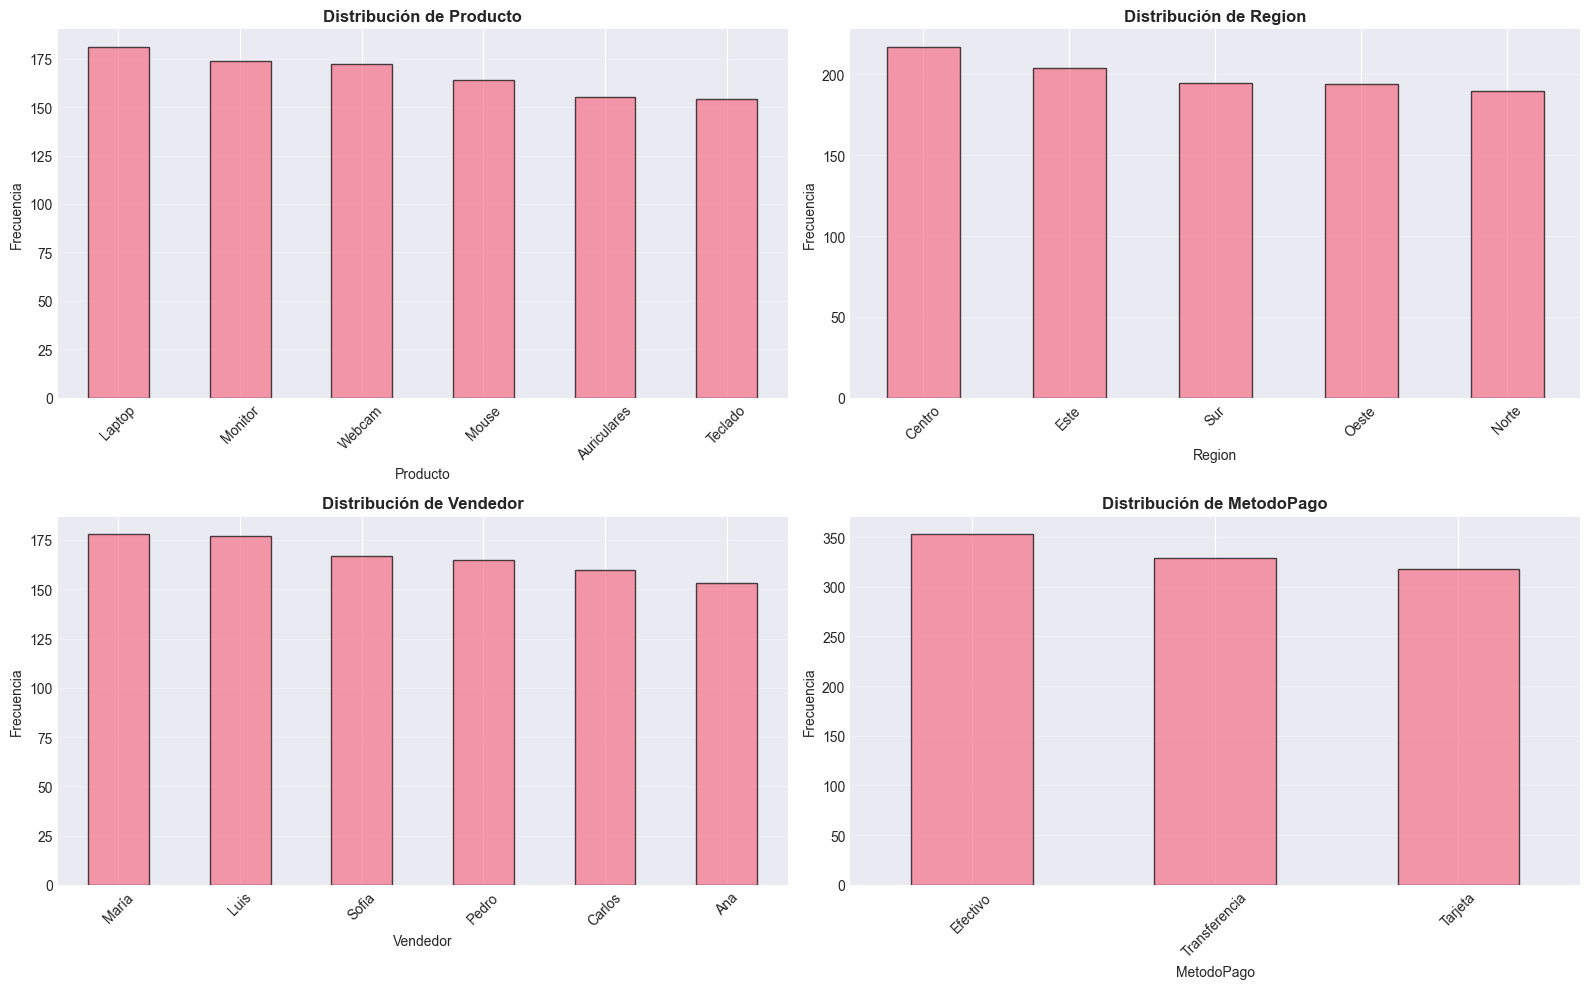

In [5]:
print("=" * 70)
print("ANÁLISIS UNIVARIADO - VARIABLES CATEGÓRICAS".center(70))
print("=" * 70)

# Conteos y frecuencias
categoricas = ['Producto', 'Region', 'Vendedor', 'MetodoPago']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(categoricas):
    print(f"\n{i+1}. {col.upper()}")
    conteo = df[col].value_counts()
    print(conteo)
    print(f"Porcentaje:\n{df[col].value_counts(normalize=True) * 100}")
    
    # Gráfico de barras
    conteo.plot(kind='bar', ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribución de {col}', fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Análisis Bivariado

### ¿Qué es?

El **análisis bivariado** estudia la relación entre dos variables para determinar si existe asociación, correlación o dependencia entre ellas. Se aplica a tres combinaciones posibles: numérico vs numérico, categórico vs numérico, y categórico vs categórico.

**Métodos según combinación de variables:**

| Combinación | Método estadístico | Visualización |
|---|---|---|
| **Numérico vs Numérico** | Coeficiente de correlación de Pearson ($r$) | Scatter plot con línea de tendencia |
| **Categórico vs Numérico** | Comparación de medias/medianas por grupo | Box plot, violin plot, barras |
| **Categórico vs Categórico** | Tablas de contingencia, Chi-cuadrado | Barras apiladas, heatmap |

**Interpretación del coeficiente de correlación ($r$):**

| Valor de $r$ | Interpretación |
|---|---|
| 0.00 – 0.30 | Correlación débil |
| 0.30 – 0.70 | Correlación moderada |
| 0.70 – 1.00 | Correlación fuerte |
| Signo + / − | Relación directa / inversa |

### ¿Para qué sirve?

El análisis bivariado sirve para:

- **Identificar relaciones entre variables** que pueden ser predictivas o causales
- **Cuantificar la fuerza de asociación** mediante coeficientes de correlación
- **Comparar distribuciones entre grupos** para detectar diferencias significativas
- **Detectar variables redundantes** que están altamente correlacionadas entre sí
- **Guiar la selección de features** para modelos de Machine Learning
- **Generar hipótesis** sobre qué variables influyen en el resultado de interés

### ¿Cómo se usa?

En el código siguiente, analizamos relaciones numérico vs numérico (Precio-Ingresos, Cantidad-Ingresos, Descuento-Ingresos) con scatter plots y correlaciones, y categórico vs numérico (Ingresos por Producto, Región, Método de Pago y Vendedor) con box plots, violin plots y barras.

              ANÁLISIS BIVARIADO - NUMÉRICO vs NUMÉRICO               


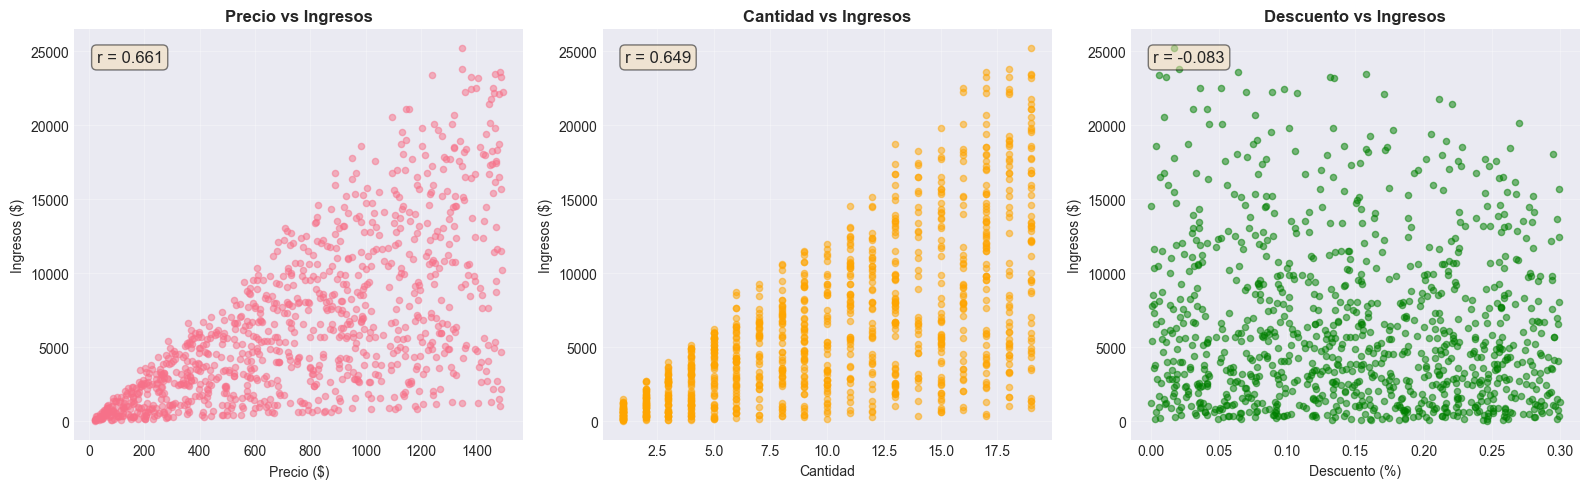


COEFICIENTES DE CORRELACIÓN:
Precio - Ingresos: 0.661
Cantidad - Ingresos: 0.649
Descuento - Ingresos: -0.083


In [6]:
print("=" * 70)
print("ANÁLISIS BIVARIADO - NUMÉRICO vs NUMÉRICO".center(70))
print("=" * 70)

# Gráficos de dispersión
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Precio vs Ingresos
axes[0].scatter(df['Precio'], df['Ingresos'], alpha=0.5, s=20)
axes[0].set_xlabel('Precio ($)')
axes[0].set_ylabel('Ingresos ($)')
axes[0].set_title('Precio vs Ingresos', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Correlación
corr = df['Precio'].corr(df['Ingresos'])
axes[0].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0].transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Cantidad vs Ingresos
axes[1].scatter(df['Cantidad'], df['Ingresos'], alpha=0.5, s=20, color='orange')
axes[1].set_xlabel('Cantidad')
axes[1].set_ylabel('Ingresos ($)')
axes[1].set_title('Cantidad vs Ingresos', fontweight='bold')
axes[1].grid(True, alpha=0.3)

corr = df['Cantidad'].corr(df['Ingresos'])
axes[1].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[1].transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Descuento vs Ingresos
axes[2].scatter(df['Descuento'], df['Ingresos'], alpha=0.5, s=20, color='green')
axes[2].set_xlabel('Descuento (%)')
axes[2].set_ylabel('Ingresos ($)')
axes[2].set_title('Descuento vs Ingresos', fontweight='bold')
axes[2].grid(True, alpha=0.3)

corr = df['Descuento'].corr(df['Ingresos'])
axes[2].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[2].transAxes, 
            fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nCOEFICIENTES DE CORRELACIÓN:")
print(f"Precio - Ingresos: {df['Precio'].corr(df['Ingresos']):.3f}")
print(f"Cantidad - Ingresos: {df['Cantidad'].corr(df['Ingresos']):.3f}")
print(f"Descuento - Ingresos: {df['Descuento'].corr(df['Ingresos']):.3f}")

             ANÁLISIS BIVARIADO - CATEGÓRICO vs NUMÉRICO              


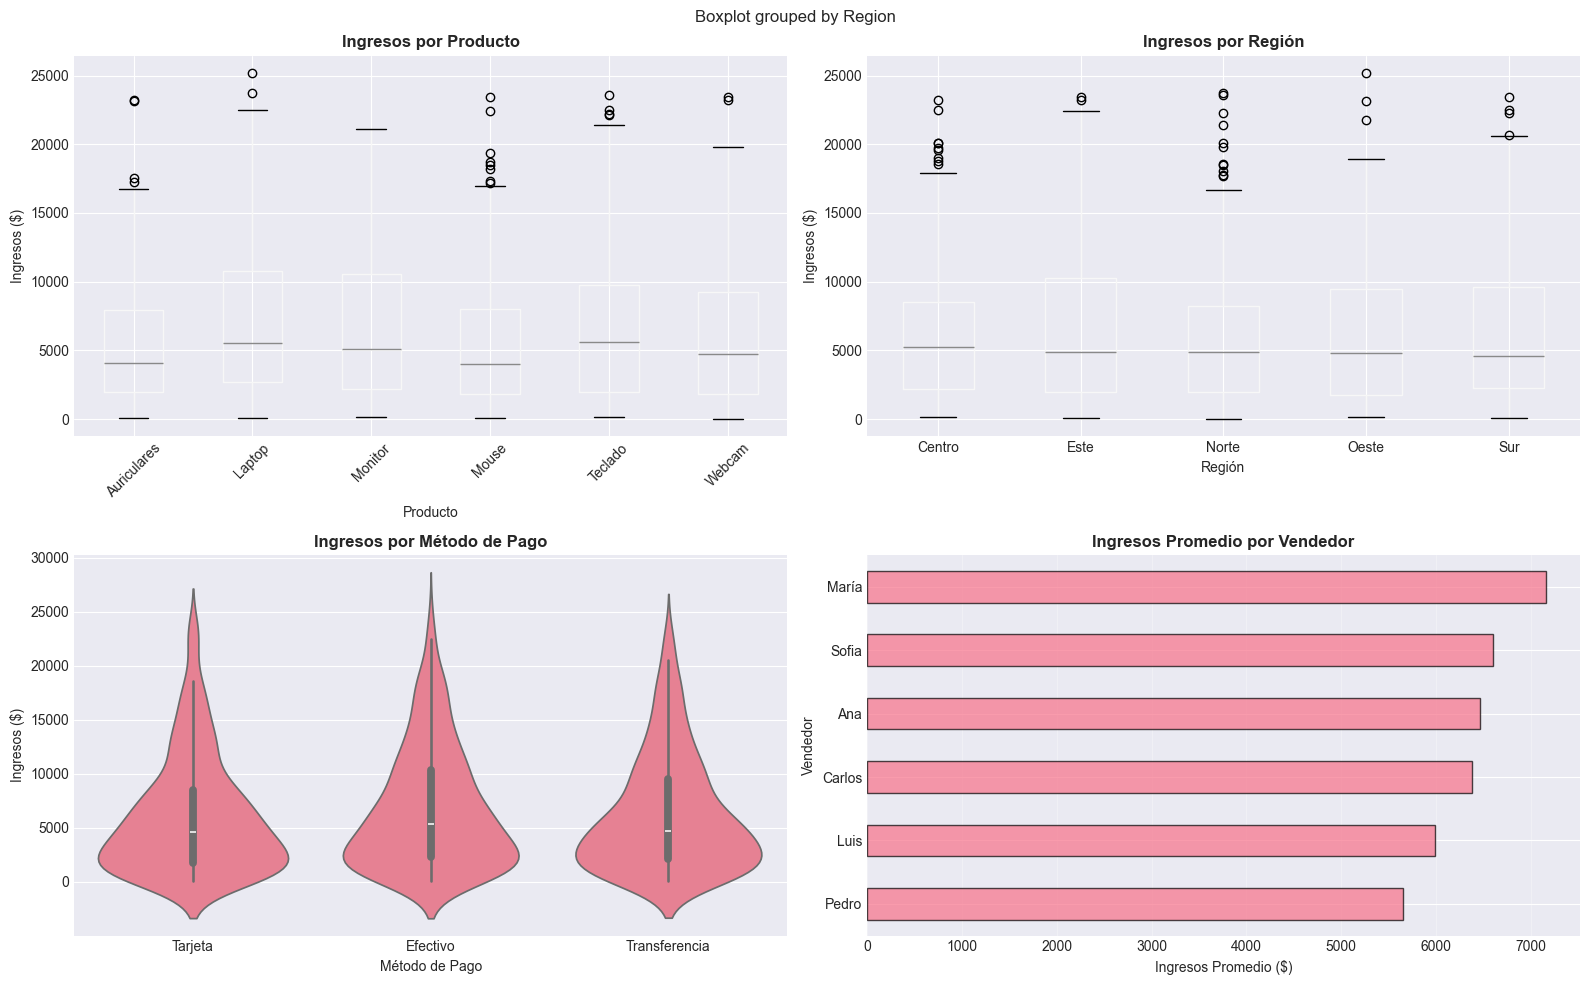


ESTADÍSTICAS POR PRODUCTO:
                mean   median      std  count
Producto                                     
Auriculares  5613.60  4047.16  4923.11    155
Laptop       7441.05  5548.20  6073.19    181
Monitor      6482.27  5097.64  5188.49    174
Mouse        5634.51  3986.10  5111.54    164
Teclado      6717.18  5630.11  5790.55    154
Webcam       6241.59  4752.55  5396.67    172

ESTADÍSTICAS POR REGIÓN:
           mean   median      std  count
Region                                  
Centro  6333.59  5227.17  5247.96    217
Este    6668.89  4857.12  5868.73    204
Norte   6191.46  4877.24  5449.63    190
Oeste   6361.46  4840.37  5291.64    194
Sur     6315.74  4574.13  5478.90    195


In [7]:
print("=" * 70)
print("ANÁLISIS BIVARIADO - CATEGÓRICO vs NUMÉRICO".center(70))
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Ingresos por Producto
df.boxplot(column='Ingresos', by='Producto', ax=axes[0, 0])
axes[0, 0].set_title('Ingresos por Producto', fontweight='bold')
axes[0, 0].set_xlabel('Producto')
axes[0, 0].set_ylabel('Ingresos ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
plt.sca(axes[0, 0])
plt.xticks(rotation=45)

# Ingresos por Región
df.boxplot(column='Ingresos', by='Region', ax=axes[0, 1])
axes[0, 1].set_title('Ingresos por Región', fontweight='bold')
axes[0, 1].set_xlabel('Región')
axes[0, 1].set_ylabel('Ingresos ($)')

# Violin plot - Ingresos por Método de Pago

sns.violinplot(data=df, x='MetodoPago', y='Ingresos', ax=axes[1, 0])
axes[1, 0].set_title('Ingresos por Método de Pago', fontweight='bold')
axes[1, 0].set_xlabel('Método de Pago')
axes[1, 0].set_ylabel('Ingresos ($)')

# Promedio de Ingresos por Vendedor
promedio_vendedor = df.groupby('Vendedor')['Ingresos'].mean().sort_values()
promedio_vendedor.plot(kind='barh', ax=axes[1, 1], edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Ingresos Promedio por Vendedor', fontweight='bold')
axes[1, 1].set_xlabel('Ingresos Promedio ($)')
axes[1, 1].set_ylabel('Vendedor')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas por grupo
print("\nESTADÍSTICAS POR PRODUCTO:")
print(df.groupby('Producto')['Ingresos'].agg(['mean', 'median', 'std', 'count']).round(2))

print("\nESTADÍSTICAS POR REGIÓN:")
print(df.groupby('Region')['Ingresos'].agg(['mean', 'median', 'std', 'count']).round(2))

## 4. Análisis Multivariado

### ¿Qué es?

El **análisis multivariado** estudia las relaciones e interacciones entre tres o más variables simultáneamente. Va más allá del análisis bivariado al revelar patrones complejos que solo emergen cuando se consideran múltiples dimensiones a la vez.

**Técnicas principales:**

| Técnica | Descripción | Visualización |
|---|---|---|
| **Matriz de correlación** | Correlaciones entre todas las variables numéricas | Heatmap con `sns.heatmap()` |
| **Scatter matrix** | Scatter plots de todos los pares de variables | `scatter_matrix()` / `sns.pairplot()` |
| **Pivot tables** | Cruce de dos categóricas con una numérica | Heatmap de tabla pivotada |
| **Scatter con dimensiones** | Color, tamaño y forma como variables adicionales | Scatter con `hue`, `size`, `style` |
| **Barras agrupadas** | Numérica cruzada por dos categóricas | Barras lado a lado |

### ¿Para qué sirve?

El análisis multivariado sirve para:

- **Visualizar todas las correlaciones a la vez** identificando rápidamente las más fuertes y débiles
- **Descubrir interacciones ocultas** entre variables que no se detectan en análisis bivariado
- **Cruzar múltiples dimensiones** como producto × región × método de pago en un solo análisis
- **Identificar multicolinealidad** entre variables predictoras antes de modelar
- **Representar información densa** codificando variables adicionales en color, tamaño o forma
- **Generar vistas resumen** que faciliten la toma de decisiones con múltiples variables

### ¿Cómo se usa?

En el código siguiente, construimos la matriz de correlación con heatmap, la scatter matrix para todas las variables numéricas, un pivot table de ingresos por producto y región, y gráficos de dispersión con tres dimensiones (precio, cantidad, ingresos por producto) y barras agrupadas por región y método de pago.

                        ANÁLISIS MULTIVARIADO                         

1. MATRIZ DE CORRELACIÓN
           Precio  Cantidad  Descuento  Ingresos
Precio      1.000     0.015      0.020     0.661
Cantidad    0.015     1.000      0.018     0.649
Descuento   0.020     0.018      1.000    -0.083
Ingresos    0.661     0.649     -0.083     1.000


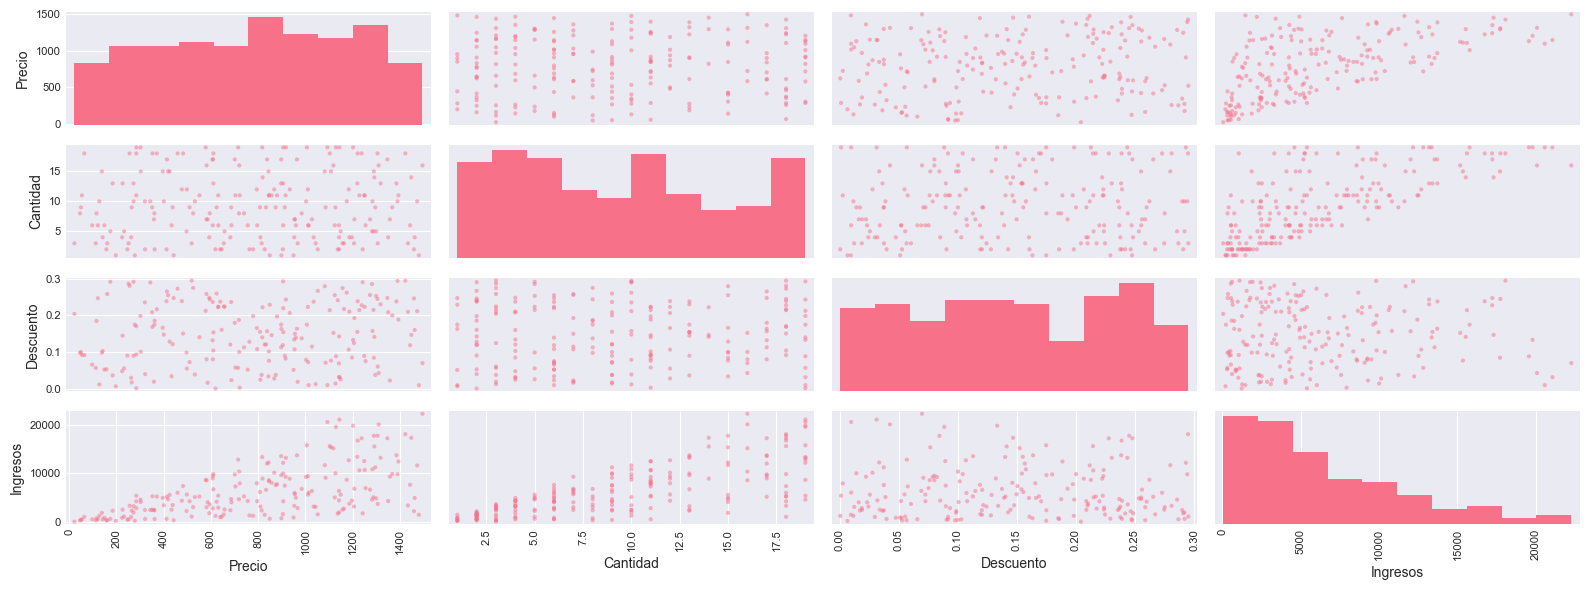


2. ANÁLISIS POR PRODUCTO Y REGIÓN
Region          Centro       Este      Norte      Oeste        Sur
Producto                                                          
Auriculares  174152.38  209397.24  127594.58  244697.33  114266.57
Laptop       328055.16  254342.13  258130.53  235271.00  271031.34
Monitor      268308.89  197478.43  243312.29  184178.57  234637.32
Mouse        161624.06  195801.23  146578.21  232768.41  187287.57
Teclado      149556.63  259507.53  255327.70  175228.89  194824.21
Webcam       292692.11  243926.95  145433.53  161978.39  229521.68


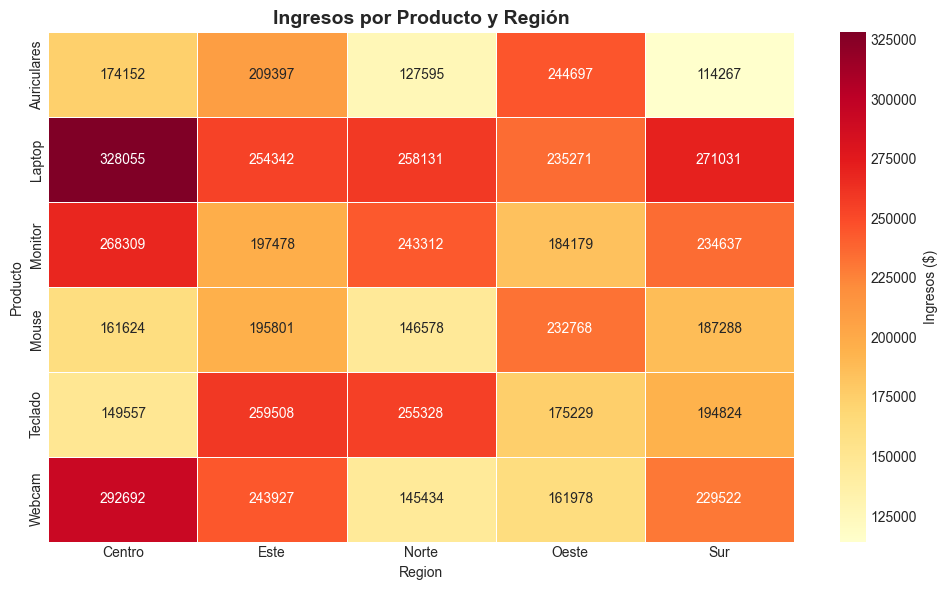

In [8]:
print("=" * 70)
print("ANÁLISIS MULTIVARIADO".center(70))
print("=" * 70)

# Matriz de correlación
print("\n1. MATRIZ DE CORRELACIÓN")
columnas_numericas = ['Precio', 'Cantidad', 'Descuento', 'Ingresos']
matriz_corr = df[columnas_numericas].corr()
print(matriz_corr.round(3))

# Heatmap de correlación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, ax=axes[0], cbar_kws={"shrink": 0.8})
axes[0].set_title('Matriz de Correlación', fontweight='bold', fontsize=14)

# Pairplot para múltiples variables
# Crear submuestra para visualización más rápida
df_sample = df[columnas_numericas].sample(200, random_state=42)
pd.plotting.scatter_matrix(df_sample, figsize=(12, 12), diagonal='hist', ax=axes[1])
axes[1].set_title('Scatter Matrix', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

# Análisis por múltiples dimensiones
print("\n2. ANÁLISIS POR PRODUCTO Y REGIÓN")
pivot_ingresos = df.pivot_table(values='Ingresos', 
                                 index='Producto', 
                                 columns='Region', 
                                 aggfunc='sum')
print(pivot_ingresos.round(2))

# Heatmap del pivot
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_ingresos, annot=True, fmt='.0f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Ingresos ($)'})
plt.title('Ingresos por Producto y Región', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


3. ANÁLISIS TRIDIMENSIONAL


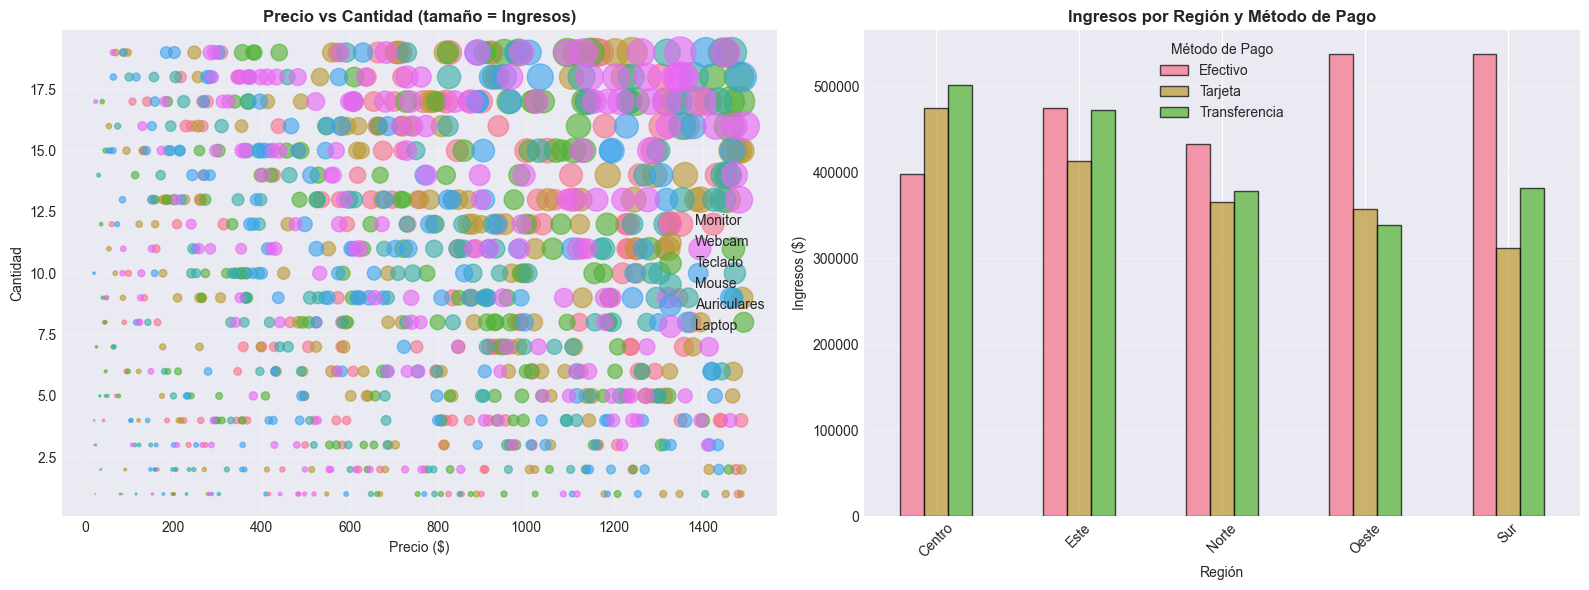

In [9]:
# Análisis de tres variables
print("\n3. ANÁLISIS TRIDIMENSIONAL")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter con color por categoría
for producto in df['Producto'].unique():
    subset = df[df['Producto'] == producto]
    axes[0].scatter(subset['Precio'], subset['Cantidad'], 
                   s=subset['Ingresos']/50, alpha=0.6, label=producto)

axes[0].set_xlabel('Precio ($)')
axes[0].set_ylabel('Cantidad')
axes[0].set_title('Precio vs Cantidad (tamaño = Ingresos)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Análisis por región y método de pago
pivot_metodo = df.pivot_table(values='Ingresos',
                               index='Region',
                               columns='MetodoPago',
                               aggfunc='sum')

pivot_metodo.plot(kind='bar', ax=axes[1], edgecolor='black', alpha=0.7)
axes[1].set_title('Ingresos por Región y Método de Pago', fontweight='bold')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Ingresos ($)')
axes[1].legend(title='Método de Pago')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Detección de Patrones y Tendencias

### ¿Qué es?

La **detección de patrones y tendencias** consiste en identificar comportamientos recurrentes o direcciones en los datos a lo largo del tiempo u otras dimensiones. Es especialmente relevante cuando el dataset tiene una componente temporal, ya que permite descubrir estacionalidad, ciclos y picos de actividad.

**Tipos de patrones temporales:**

| Patrón | Descripción | Ejemplo |
|---|---|---|
| **Tendencia** | Dirección general a largo plazo | Ventas crecientes mes a mes |
| **Estacionalidad** | Patrón repetitivo en periodos fijos | Más ventas en diciembre |
| **Ciclo** | Fluctuaciones irregulares a largo plazo | Ciclos económicos |
| **Picos** | Puntos extremos en momentos específicos | Hora pico de ventas |

### ¿Para qué sirve?

La detección de patrones y tendencias sirve para:

- **Identificar las horas, días y meses de mayor actividad** para optimizar recursos y staffing
- **Descubrir estacionalidad** que permita planificar inventario y campañas con anticipación
- **Detectar tendencias de crecimiento o declive** para ajustar estrategias de negocio
- **Encontrar ciclos de comportamiento** que se repiten y pueden predecirse
- **Fundamentar decisiones operativas** como horarios de atención, turnos y promociones

### ¿Cómo se usa?

En el código siguiente, analizamos patrones de ventas por hora del día, día de la semana y mes, visualizando cada uno con gráficos de línea y barras, e identificando los picos de mayor actividad.

                  DETECCIÓN DE PATRONES Y TENDENCIAS                  

1. PATRONES TEMPORALES


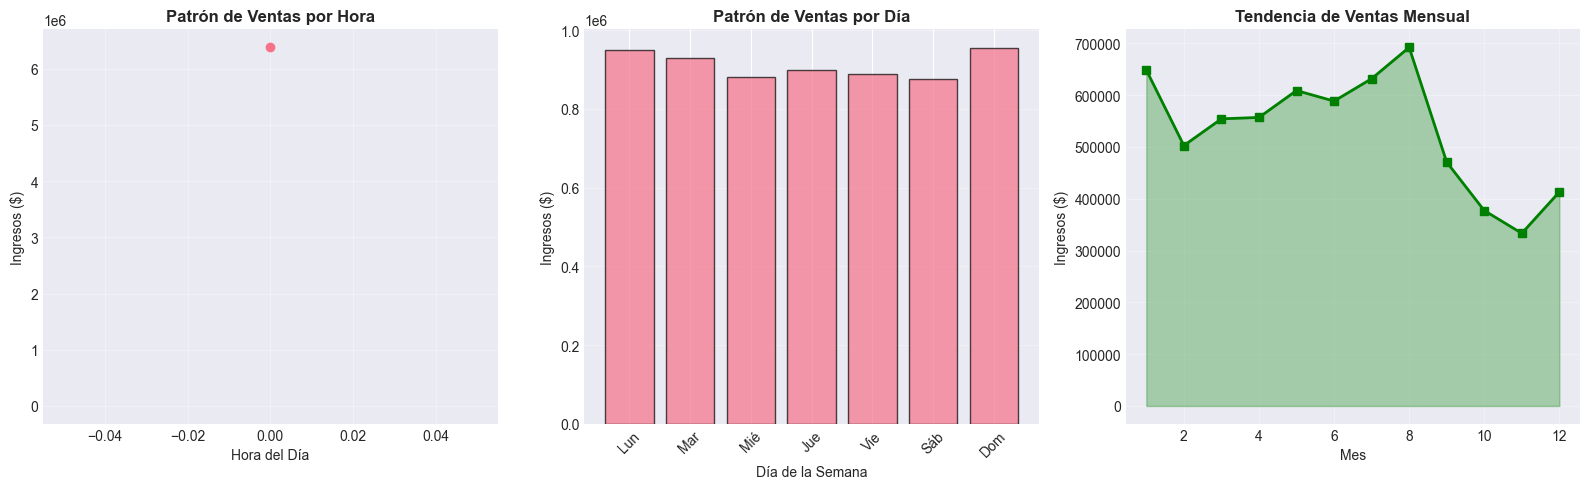


HORA PICO DE VENTAS:
Hora: 0:00 hrs
Ingresos: $6,376,910.88

DÍA PICO DE VENTAS:
Día: Sunday
Ingresos: $954,077.02


In [10]:
print("=" * 70)
print("DETECCIÓN DE PATRONES Y TENDENCIAS".center(70))
print("=" * 70)

# Tendencias temporales
print("\n1. PATRONES TEMPORALES")

# Ventas por hora del día
ventas_hora = df.groupby('Hora')['Ingresos'].sum()

# Ventas por día de la semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dia = df.groupby('DiaSemana')['Ingresos'].sum().reindex(orden_dias)

# Ventas por mes
ventas_mes = df.groupby('Mes')['Ingresos'].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Por hora
axes[0].plot(ventas_hora.index, ventas_hora.values, marker='o', linewidth=2)
axes[0].fill_between(ventas_hora.index, ventas_hora.values, alpha=0.3)
axes[0].set_xlabel('Hora del Día')
axes[0].set_ylabel('Ingresos ($)')
axes[0].set_title('Patrón de Ventas por Hora', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Por día de semana
axes[1].bar(range(7), ventas_dia.values, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Ingresos ($)')
axes[1].set_title('Patrón de Ventas por Día', fontweight='bold')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom'], rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Por mes
axes[2].plot(ventas_mes.index, ventas_mes.values, marker='s', linewidth=2, color='green')
axes[2].fill_between(ventas_mes.index, ventas_mes.values, alpha=0.3, color='green')
axes[2].set_xlabel('Mes')
axes[2].set_ylabel('Ingresos ($)')
axes[2].set_title('Tendencia de Ventas Mensual', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identificar picos
print("\nHORA PICO DE VENTAS:")
hora_pico = ventas_hora.idxmax()
print(f"Hora: {hora_pico}:00 hrs")
print(f"Ingresos: ${ventas_hora.max():,.2f}")

print("\nDÍA PICO DE VENTAS:")
dia_pico = ventas_dia.idxmax()
print(f"Día: {dia_pico}")
print(f"Ingresos: ${ventas_dia.max():,.2f}")

## 6. Análisis de Correlaciones

### ¿Qué es?

El **análisis de correlaciones** profundiza en las relaciones lineales entre variables numéricas, incorporando pruebas de significancia estadística (valores p) para determinar si las correlaciones observadas son estadísticamente significativas o podrían deberse al azar.

**Componentes del análisis:**

| Componente | Descripción | Interpretación |
|---|---|---|
| **Coeficiente $r$** | Fuerza y dirección de la relación lineal | −1 a +1 (0 = sin relación lineal) |
| **Valor $p$** | Probabilidad de observar $r$ por azar | $p < 0.05$: significativo |
| **Significancia** | Nivel de confianza en la correlación | `***` $p<0.001$, `**` $p<0.01$, `*` $p<0.05$, `ns` no significativo |
| **Línea de tendencia** | Recta de regresión ajustada | Visualiza la dirección de la relación |

### ¿Para qué sirve?

El análisis de correlaciones sirve para:

- **Validar estadísticamente las relaciones** distinguiendo correlaciones reales de coincidencias
- **Rankear las correlaciones** por fuerza para priorizar las más relevantes
- **Identificar las variables más predictivas** del resultado de interés
- **Visualizar la relación más fuerte** con scatter plot y línea de tendencia
- **Detectar correlaciones espurias** que no tienen valor p significativo
- **Fundamentar la selección de features** con evidencia estadística

### ¿Cómo se usa?

En el código siguiente, calculamos correlaciones de Pearson con valores p y significancia estadística para todos los pares de variables numéricas, rankeamos por fuerza de correlación, y visualizamos la relación más fuerte con scatter plot y línea de tendencia.

                 ANÁLISIS DETALLADO DE CORRELACIONES                  

1. CORRELACIONES CON VALORES P
Precio vs Cantidad: r = 0.015, p = 0.6296 ns
Precio vs Descuento: r = 0.020, p = 0.5194 ns
Precio vs Ingresos: r = 0.661, p = 0.0000 ***
Cantidad vs Descuento: r = 0.018, p = 0.5769 ns
Cantidad vs Ingresos: r = 0.649, p = 0.0000 ***
Descuento vs Ingresos: r = -0.083, p = 0.0087 **

2. RANKING DE CORRELACIONES
  Variable 1 Variable 2  Correlación
2     Precio   Ingresos     0.661327
4   Cantidad   Ingresos     0.648727
5  Descuento   Ingresos    -0.082982
1     Precio  Descuento     0.020399
3   Cantidad  Descuento     0.017666
0     Precio   Cantidad     0.015271


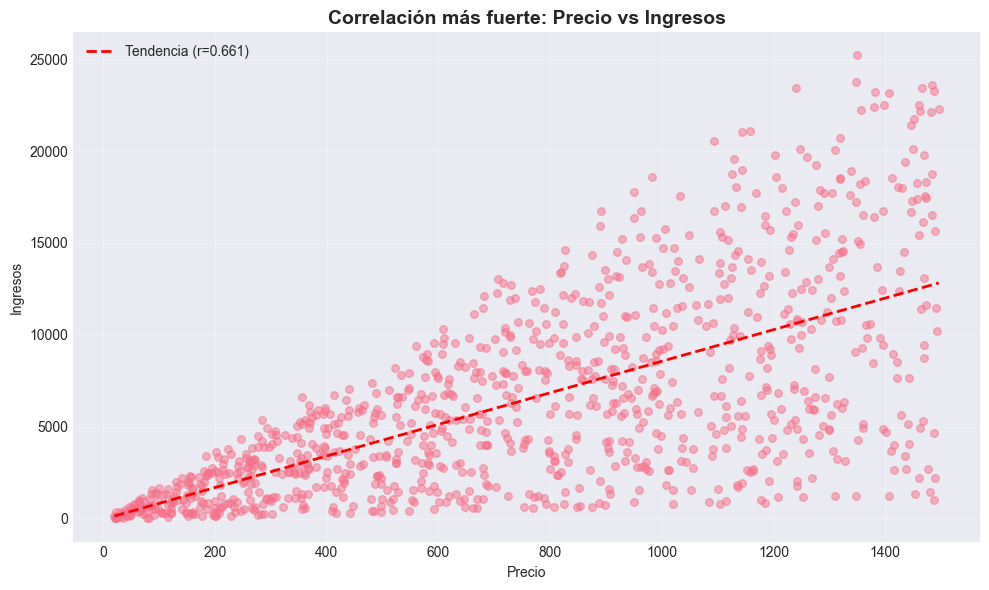

In [12]:
print("=" * 70)
print("ANÁLISIS DETALLADO DE CORRELACIONES".center(70))
print("=" * 70)

# Correlaciones con significancia estadística
from scipy.stats import pearsonr

print("\n1. CORRELACIONES CON VALORES P")
variables = ['Precio', 'Cantidad', 'Descuento', 'Ingresos']

for i in range(len(variables)):
    for j in range(i+1, len(variables)):
        var1, var2 = variables[i], variables[j]
        corr, p_value = pearsonr(df[var1], df[var2])
        significancia = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        print(f"{var1} vs {var2}: r = {corr:.3f}, p = {p_value:.4f} {significancia}")

# Correlaciones más fuertes
print("\n2. RANKING DE CORRELACIONES")
matriz_corr = df[variables].corr()

# Convertir a formato largo y ordenar
correlaciones = []
for i in range(len(variables)):
    for j in range(i+1, len(variables)):
        correlaciones.append({
            'Variable 1': variables[i],
            'Variable 2': variables[j],
            'Correlación': matriz_corr.iloc[i, j]
        })

df_corr = pd.DataFrame(correlaciones).sort_values('Correlación', key=abs, ascending=False)
print(df_corr)

# Visualización de correlación más fuerte
top_corr = df_corr.iloc[0]
var1, var2 = top_corr['Variable 1'], top_corr['Variable 2']

plt.figure(figsize=(10, 6))
plt.scatter(df[var1], df[var2], alpha=0.5, s=30)

# Línea de tendencia
z = np.polyfit(df[var1], df[var2], 1)
p = np.poly1d(z)
plt.plot(df[var1].sort_values(), p(df[var1].sort_values()), 
         "r--", linewidth=2, label=f'Tendencia (r={top_corr["Correlación"]:.3f})')

plt.xlabel(var1)
plt.ylabel(var2)
plt.title(f'Correlación más fuerte: {var1} vs {var2}', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Identificación de Anomalías

### ¿Qué es?

La **identificación de anomalías** (outlier detection) es el proceso de encontrar observaciones que se desvían significativamente del comportamiento general de los datos. Los dos métodos más utilizados son el **IQR** (basado en cuartiles) y el **Z-score** (basado en desviaciones estándar).

**Comparación de métodos:**

| Método | Criterio | Ventaja | Limitación |
|---|---|---|---|
| **IQR** | Fuera de [Q1 − 1.5×IQR, Q3 + 1.5×IQR] | Robusto ante distribuciones no normales | Puede ser conservador |
| **Z-score** | $\|z\| > 3$ (más de 3σ de la media) | Intuitivo, basado en desviaciones estándar | Asume distribución normal |

### ¿Para qué sirve?

La identificación de anomalías sirve para:

- **Detectar errores de datos** como valores negativos, extremos o imposibles
- **Identificar transacciones atípicas** que pueden ser fraude, errores de sistema o casos excepcionales
- **Cuantificar la proporción de outliers** para evaluar la calidad general del dataset
- **Comparar métodos de detección** y elegir el más adecuado según la distribución de los datos
- **Decidir el tratamiento** adecuado: eliminar, capping, transformar o mantener los outliers
- **Documentar umbrales de aceptación** para monitoreo continuo de calidad

### ¿Cómo se usa?

En el código siguiente, aplicamos los métodos IQR y Z-score a cada variable numérica (Precio, Cantidad, Descuento, Ingresos), visualizamos los outliers en box plots con los límites marcados, y reportamos la cantidad y porcentaje de anomalías detectadas por cada método.

                     IDENTIFICACIÓN DE ANOMALÍAS                      

1. DETECCIÓN CON IQR

Precio:
  Límite inferior: -739.98
  Límite superior: 2221.86
  Outliers detectados: 0 (0.00%)

Cantidad:
  Límite inferior: -10.00
  Límite superior: 30.00
  Outliers detectados: 0 (0.00%)

Descuento:
  Límite inferior: -0.14
  Límite superior: 0.44
  Outliers detectados: 0 (0.00%)

Ingresos:
  Límite inferior: -9046.09
  Límite superior: 20511.82
  Outliers detectados: 21 (2.10%)


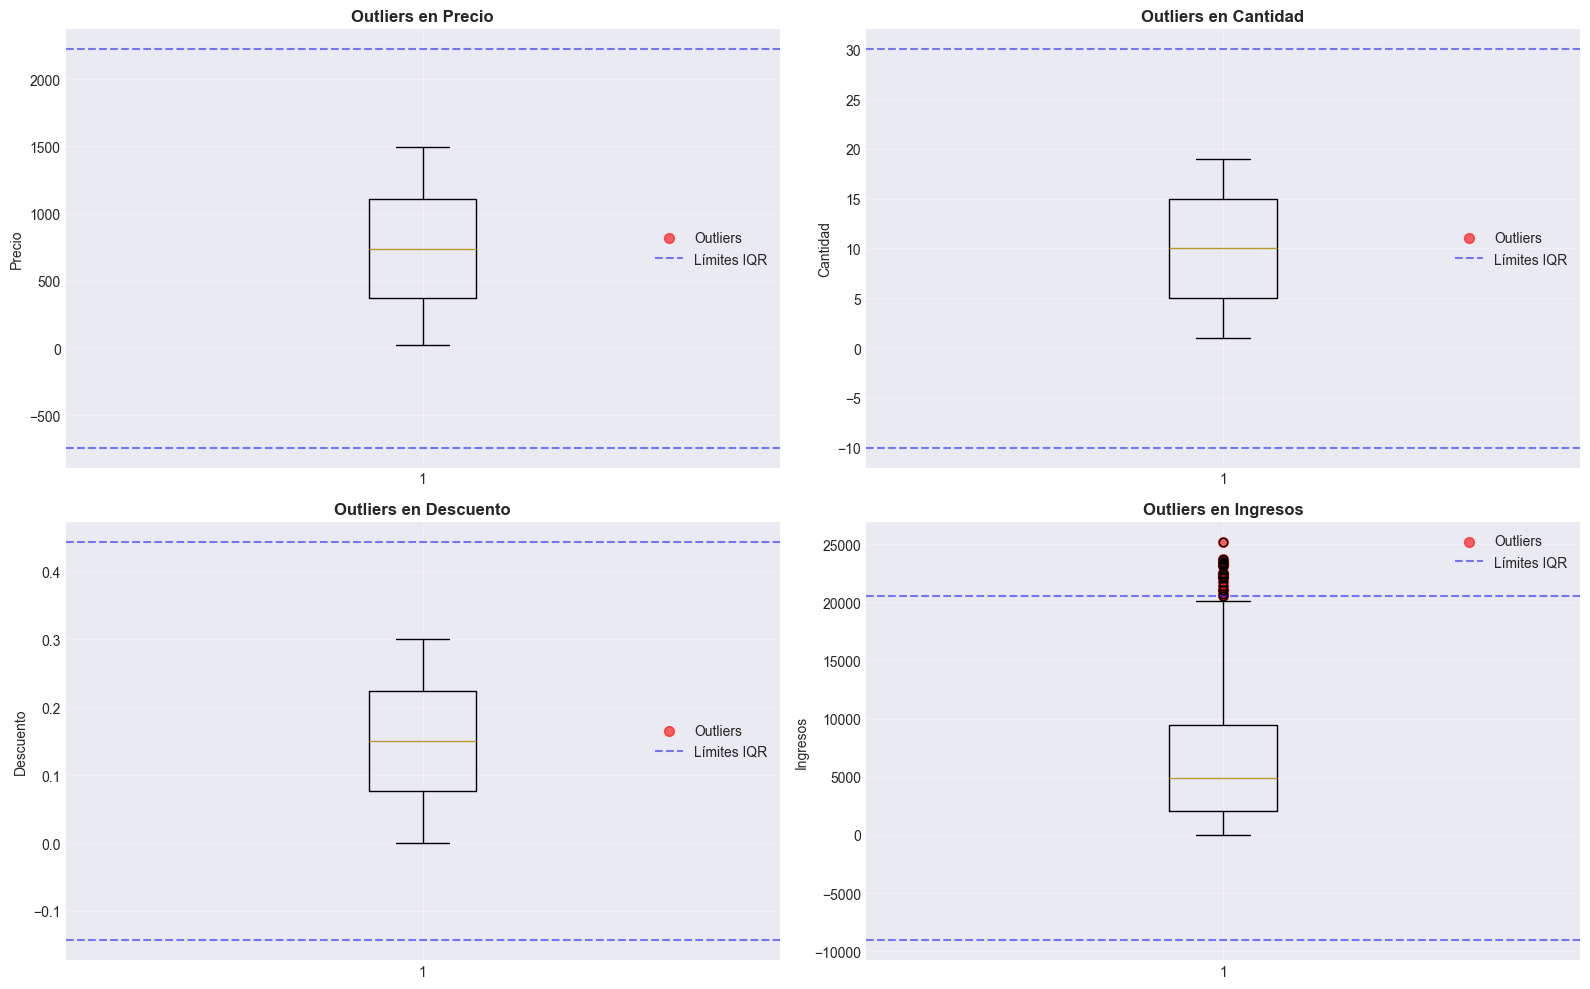


2. DETECCIÓN CON Z-SCORE (|z| > 3)
Precio: 0 outliers (0.00%)
Cantidad: 0 outliers (0.00%)
Descuento: 0 outliers (0.00%)
Ingresos: 8 outliers (0.80%)


In [13]:
print("=" * 70)
print("IDENTIFICACIÓN DE ANOMALÍAS".center(70))
print("=" * 70)

# Método 1: IQR (Rango Intercuartílico)
print("\n1. DETECCIÓN CON IQR")

def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

variables_analizar = ['Precio', 'Cantidad', 'Descuento', 'Ingresos']

for i, var in enumerate(variables_analizar):
    outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, var)
    
    print(f"\n{var}:")
    print(f"  Límite inferior: {lim_inf:.2f}")
    print(f"  Límite superior: {lim_sup:.2f}")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    
    # Box plot con outliers marcados
    axes[i].boxplot(df[var], vert=True)
    axes[i].scatter([1]*len(outliers), outliers[var], color='red', s=50, alpha=0.6, label='Outliers')
    axes[i].axhline(lim_inf, color='blue', linestyle='--', alpha=0.5, label='Límites IQR')
    axes[i].axhline(lim_sup, color='blue', linestyle='--', alpha=0.5)
    axes[i].set_ylabel(var)
    axes[i].set_title(f'Outliers en {var}', fontweight='bold')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Método 2: Z-score
print("\n2. DETECCIÓN CON Z-SCORE (|z| > 3)")
from scipy.stats import zscore

for var in variables_analizar:
    z_scores = np.abs(zscore(df[var]))
    outliers_z = df[z_scores > 3]
    print(f"{var}: {len(outliers_z)} outliers ({len(outliers_z)/len(df)*100:.2f}%)")

## 8. Generación de Insights

### ¿Qué es?

La **generación de insights** es la etapa donde se transforman los hallazgos del análisis en conclusiones accionables de negocio. Implica responder preguntas concretas como "¿cuál es el producto más rentable?", "¿qué región lidera en ventas?" o "¿cuál es el impacto de los descuentos?", apoyándose en las estadísticas y visualizaciones del EDA.

**Tipos de insights:**

| Tipo | Descripción | Ejemplo |
|---|---|---|
| **Descriptivo** | Qué pasó | "El producto X generó $100K en ingresos" |
| **Diagnóstico** | Por qué pasó | "La región Norte lidera por mayor ticket promedio" |
| **Predictivo** | Qué podría pasar | "Si se mantiene la tendencia, las ventas crecerán un 10%" |
| **Prescriptivo** | Qué hacer al respecto | "Priorizar la región Norte para expansión" |

### ¿Para qué sirve?

La generación de insights sirve para:

- **Responder preguntas de negocio** con datos y evidencia concreta
- **Identificar los drivers clave** de rendimiento (mejores productos, regiones, vendedores)
- **Evaluar el impacto de variables** como descuentos, métodos de pago y temporalidad
- **Rankear y comparar categorías** para priorización estratégica
- **Detectar oportunidades** de mejora basadas en datos
- **Comunicar hallazgos** de forma clara y accionable a stakeholders

### ¿Cómo se usa?

En el código siguiente, generamos insights sobre rentabilidad por producto, desempeño por región, vendedores destacados, impacto de descuentos y preferencia de métodos de pago, resumiendo cada hallazgo con estadísticas concretas.

In [14]:
print("=" * 70)
print("GENERACIÓN DE INSIGHTS".center(70))
print("=" * 70)

# 1. Producto más rentable
print("\n1. ANÁLISIS DE RENTABILIDAD POR PRODUCTO")
rentabilidad = df.groupby('Producto').agg({
    'Ingresos': 'sum',
    'Cantidad': 'sum'
}).sort_values('Ingresos', ascending=False)
rentabilidad['Ingreso_Promedio'] = rentabilidad['Ingresos'] / rentabilidad['Cantidad']
print(rentabilidad)

print("\n📊 INSIGHT:")
producto_top = rentabilidad.index[0]
print(f"   • '{producto_top}' es el producto más rentable con ${rentabilidad.loc[producto_top, 'Ingresos']:,.2f}")
print(f"   • Ingreso promedio por unidad: ${rentabilidad.loc[producto_top, 'Ingreso_Promedio']:,.2f}")

# 2. Mejor región
print("\n2. ANÁLISIS POR REGIÓN")
region_stats = df.groupby('Region').agg({
    'Ingresos': ['sum', 'mean', 'count']
}).round(2)
region_stats.columns = ['Ingresos_Total', 'Ingresos_Promedio', 'Num_Ventas']
region_stats = region_stats.sort_values('Ingresos_Total', ascending=False)
print(region_stats)

print("\n📊 INSIGHT:")
region_top = region_stats.index[0]
print(f"   • La región '{region_top}' lidera con ${region_stats.loc[region_top, 'Ingresos_Total']:,.2f}")
print(f"   • Ticket promedio: ${region_stats.loc[region_top, 'Ingresos_Promedio']:,.2f}")

# 3. Vendedor destacado
print("\n3. DESEMPEÑO DE VENDEDORES")
vendedor_stats = df.groupby('Vendedor').agg({
    'Ingresos': ['sum', 'mean'],
    'Cantidad': 'sum'
}).round(2)
vendedor_stats.columns = ['Ingresos_Total', 'Ticket_Promedio', 'Unidades_Vendidas']
vendedor_stats = vendedor_stats.sort_values('Ingresos_Total', ascending=False)
print(vendedor_stats)

print("\n📊 INSIGHT:")
vendedor_top = vendedor_stats.index[0]
print(f"   • {vendedor_top} es el vendedor top con ${vendedor_stats.loc[vendedor_top, 'Ingresos_Total']:,.2f}")
print(f"   • Unidades vendidas: {vendedor_stats.loc[vendedor_top, 'Unidades_Vendidas']:.0f}")

# 4. Impacto del descuento
print("\n4. ANÁLISIS DE DESCUENTOS")
df['Categoria_Descuento'] = pd.cut(df['Descuento'], 
                                    bins=[0, 0.1, 0.2, 0.3],
                                    labels=['0-10%', '10-20%', '20-30%'])
descuento_impact = df.groupby('Categoria_Descuento').agg({
    'Ingresos': 'sum',
    'Cantidad': 'sum'
}).round(2)
print(descuento_impact)

print("\n📊 INSIGHT:")
mejor_rango = descuento_impact['Ingresos'].idxmax()
print(f"   • El rango de descuento '{mejor_rango}' genera más ingresos")
print(f"   • Total: ${descuento_impact.loc[mejor_rango, 'Ingresos']:,.2f}")

# 5. Método de pago preferido
print("\n5. ANÁLISIS DE MÉTODOS DE PAGO")
metodo_pago = df.groupby('MetodoPago').agg({
    'Ingresos': 'sum',
    'Cantidad': 'count'
}).round(2)
metodo_pago['Porcentaje'] = (metodo_pago['Cantidad'] / metodo_pago['Cantidad'].sum() * 100).round(2)
print(metodo_pago.sort_values('Ingresos', ascending=False))

print("\n📊 INSIGHT:")
metodo_top = metodo_pago['Ingresos'].idxmax()
print(f"   • '{metodo_top}' es el método preferido ({metodo_pago.loc[metodo_top, 'Porcentaje']:.1f}% de transacciones)")
print(f"   • Genera ${metodo_pago.loc[metodo_top, 'Ingresos']:,.2f} en ingresos")

                        GENERACIÓN DE INSIGHTS                        

1. ANÁLISIS DE RENTABILIDAD POR PRODUCTO
                 Ingresos  Cantidad  Ingreso_Promedio
Producto                                             
Laptop       1.346830e+06      2008        670.732152
Monitor      1.127916e+06      1739        648.600063
Webcam       1.073553e+06      1658        647.498594
Teclado      1.034445e+06      1582        653.884300
Mouse        9.240595e+05      1501        615.629237
Auriculares  8.701081e+05      1561        557.404287

📊 INSIGHT:
   • 'Laptop' es el producto más rentable con $1,346,830.16
   • Ingreso promedio por unidad: $670.73

2. ANÁLISIS POR REGIÓN
        Ingresos_Total  Ingresos_Promedio  Num_Ventas
Region                                               
Centro      1374389.23            6333.59         217
Este        1360453.51            6668.89         204
Oeste       1234122.59            6361.46         194
Sur         1231568.71            6315.74      

## 9. Documentación del Proceso

### ¿Qué es?

La **documentación del proceso** es la elaboración de un reporte ejecutivo que sintetiza los hallazgos más importantes del EDA en un formato comprensible para audiencias técnicas y no técnicas. Incluye un resumen del dataset, los hallazgos principales con métricas concretas y recomendaciones accionables.

**Componentes de un reporte EDA:**

| Componente | Contenido | Audiencia |
|---|---|---|
| **Resumen del dataset** | Periodo, registros, variables, cobertura | Técnica y de negocio |
| **Hallazgos principales** | Top productos, regiones, correlaciones clave | De negocio |
| **Anomalías detectadas** | Cantidad y tipo de outliers encontrados | Técnica |
| **Recomendaciones** | Acciones sugeridas basadas en los hallazgos | De negocio |
| **Próximos pasos** | Análisis adicionales o modelos a construir | Técnica |

### ¿Para qué sirve?

La documentación del proceso sirve para:

- **Comunicar resultados** de forma estructurada a equipos técnicos y de negocio
- **Dejar registro reproducible** del análisis para futuras referencias o auditorías
- **Facilitar la toma de decisiones** con evidencia resumida y recomendaciones claras
- **Identificar próximos pasos** como modelos predictivos, análisis más profundos o acciones operativas
- **Estandarizar el formato de entrega** del EDA como práctica profesional

### ¿Cómo se usa?

En el código siguiente, generamos un reporte ejecutivo con el resumen del dataset, los top 3 productos por ingresos, la región más rentable, la hora pico de ventas, la correlación clave y las anomalías detectadas, cerrando con recomendaciones accionables.

In [15]:
print("=" * 70)
print("REPORTE EJECUTIVO DE EDA".center(70))
print("=" * 70)

print("\n📋 RESUMEN DEL DATASET")
print("-" * 70)
print(f"Período analizado: {df['Fecha'].min()} a {df['Fecha'].max()}")
print(f"Total de registros: {len(df):,}")
print(f"Total de ingresos: ${df['Ingresos'].sum():,.2f}")
print(f"Ticket promedio: ${df['Ingresos'].mean():,.2f}")
print(f"Productos únicos: {df['Producto'].nunique()}")
print(f"Regiones cubiertas: {df['Region'].nunique()}")
print(f"Vendedores activos: {df['Vendedor'].nunique()}")

print("\n🎯 HALLAZGOS PRINCIPALES")
print("-" * 70)

# Top 3 productos
top3_productos = df.groupby('Producto')['Ingresos'].sum().nlargest(3)
print("\n1. TOP 3 PRODUCTOS POR INGRESOS:")
for i, (producto, ingresos) in enumerate(top3_productos.items(), 1):
    porcentaje = (ingresos / df['Ingresos'].sum()) * 100
    print(f"   {i}. {producto}: ${ingresos:,.2f} ({porcentaje:.1f}%)")

# Top región
top_region = df.groupby('Region')['Ingresos'].sum().idxmax()
ingresos_region = df.groupby('Region')['Ingresos'].sum().max()
print(f"\n2. REGIÓN MÁS RENTABLE: {top_region} (${ingresos_region:,.2f})")

# Hora pico
hora_pico = df.groupby('Hora')['Ingresos'].sum().idxmax()
print(f"\n3. HORA PICO DE VENTAS: {hora_pico}:00 hrs")

# Correlación clave
corr_precio_ingresos = df['Precio'].corr(df['Ingresos'])
print(f"\n4. CORRELACIÓN PRECIO-INGRESOS: {corr_precio_ingresos:.3f}")
if corr_precio_ingresos > 0.7:
    print("   → Correlación fuerte positiva: precios altos generan más ingresos")
elif corr_precio_ingresos > 0.3:
    print("   → Correlación moderada positiva")
else:
    print("   → Correlación débil")

# Outliers
outliers_ingresos, _, _ = detectar_outliers_iqr(df, 'Ingresos')
print(f"\n5. ANOMALÍAS DETECTADAS: {len(outliers_ingresos)} transacciones atípicas ({len(outliers_ingresos)/len(df)*100:.2f}%)")

print("\n💡 RECOMENDACIONES")
print("-" * 70)
print("1. Enfocar estrategia comercial en productos de alto valor")
print(f"2. Priorizar la región {top_region} para expansión")
print(f"3. Optimizar staffing para hora pico ({hora_pico}:00 hrs)")
print("4. Revisar estrategia de descuentos para maximizar márgenes")
print("5. Investigar transacciones atípicas para detectar problemas operacionales")

print("\n" + "=" * 70)
print("FIN DEL REPORTE EDA".center(70))
print("=" * 70)

                       REPORTE EJECUTIVO DE EDA                       

📋 RESUMEN DEL DATASET
----------------------------------------------------------------------
Período analizado: 2023-01-01 00:00:00 a 2025-09-26 00:00:00
Total de registros: 1,000
Total de ingresos: $6,376,910.88
Ticket promedio: $6,376.91
Productos únicos: 6
Regiones cubiertas: 5
Vendedores activos: 6

🎯 HALLAZGOS PRINCIPALES
----------------------------------------------------------------------

1. TOP 3 PRODUCTOS POR INGRESOS:
   1. Laptop: $1,346,830.16 (21.1%)
   2. Monitor: $1,127,915.51 (17.7%)
   3. Webcam: $1,073,552.67 (16.8%)

2. REGIÓN MÁS RENTABLE: Centro ($1,374,389.23)

3. HORA PICO DE VENTAS: 0:00 hrs

4. CORRELACIÓN PRECIO-INGRESOS: 0.661
   → Correlación moderada positiva

5. ANOMALÍAS DETECTADAS: 21 transacciones atípicas (2.10%)

💡 RECOMENDACIONES
----------------------------------------------------------------------
1. Enfocar estrategia comercial en productos de alto valor
2. Priorizar la regi

## 10. Ejercicio Práctico Integrador: Plantilla de EDA

### ¿Qué es?

Un **ejercicio integrador** que presenta la plantilla completa de los 8 pasos para realizar un EDA profesional. Sirve como checklist de referencia para aplicar a cualquier dataset nuevo, asegurando que no se omita ninguna etapa del proceso.

**Checklist del EDA completo:**

| Paso | Etapa | Entregables |
|---|---|---|
| 1 | Exploración inicial | Dimensiones, tipos, faltantes, `describe()` |
| 2 | Análisis univariado | Histogramas, box plots, frecuencias |
| 3 | Análisis bivariado | Scatter plots, correlaciones, box plots por grupo |
| 4 | Análisis multivariado | Heatmap de correlación, pair plots, pivots |
| 5 | Detección de patrones | Tendencias temporales, estacionalidad |
| 6 | Identificación de anomalías | Outliers por IQR y Z-score |
| 7 | Generación de insights | Rankings, KPIs, respuestas a preguntas de negocio |
| 8 | Documentación | Reporte ejecutivo con hallazgos y recomendaciones |

### ¿Para qué sirve?

El ejercicio integrador sirve para:

- **Tener una plantilla reutilizable** que se pueda aplicar a cualquier dataset nuevo
- **No olvidar ningún paso** del proceso de EDA al seguir el checklist completo
- **Exportar resultados clave** como estadísticas descriptivas y matrices de correlación a CSV
- **Practicar el flujo completo** desde la exploración inicial hasta la documentación final

### ¿Cómo se usa?

En el código siguiente, se presenta la plantilla completa con los 8 pasos y sus sub-tareas, y se exportan las estadísticas descriptivas y la matriz de correlación a archivos CSV como entregables del análisis.

In [16]:
# Crear tu propio análisis EDA completo
print("""\n
═══════════════════════════════════════════════════════════════════════
                    PLANTILLA DE ANÁLISIS EDA
═══════════════════════════════════════════════════════════════════════

PASOS PARA REALIZAR UN EDA COMPLETO:

1. EXPLORACIÓN INICIAL
   □ Cargar datos
   □ Verificar dimensiones (shape)
   □ Revisar tipos de datos (dtypes)
   □ Identificar valores faltantes
   □ Estadísticas descriptivas (describe())

2. ANÁLISIS UNIVARIADO
   □ Distribuciones de variables numéricas (histogramas, box plots)
   □ Frecuencias de variables categóricas (barras, pie charts)
   □ Medidas de tendencia central y dispersión
   □ Identificar asimetría y curtosis

3. ANÁLISIS BIVARIADO
   □ Correlaciones entre variables numéricas (scatter plots)
   □ Relaciones categórico-numérico (box plots por grupo)
   □ Tablas de contingencia para categóricas
   □ Calcular coeficientes de correlación

4. ANÁLISIS MULTIVARIADO
   □ Matriz de correlación (heatmap)
   □ Pair plots / scatter matrix
   □ Análisis por múltiples dimensiones
   □ Pivot tables y agregaciones complejas

5. DETECCIÓN DE PATRONES
   □ Tendencias temporales
   □ Estacionalidad
   □ Ciclos y periodicidad
   □ Segmentación de datos

6. IDENTIFICACIÓN DE ANOMALÍAS
   □ Método IQR
   □ Método Z-score
   □ Análisis de valores extremos
   □ Validación de datos inconsistentes

7. GENERACIÓN DE INSIGHTS
   □ Responder preguntas de negocio
   □ Identificar drivers clave
   □ Encontrar oportunidades
   □ Detectar problemas

8. DOCUMENTACIÓN
   □ Resumen ejecutivo
   □ Hallazgos principales
   □ Visualizaciones clave
   □ Recomendaciones

═══════════════════════════════════════════════════════════════════════
                    ¡COMPLETA TU PROPIO EDA!
═══════════════════════════════════════════════════════════════════════
""")

# Exportar reporte
print("\n💾 Guardando resultados del análisis...")

# Guardar estadísticas principales
estadisticas = df.describe()
estadisticas.to_csv('eda_estadisticas_descriptivas.csv')

# Guardar correlaciones
matriz_corr = df[['Precio', 'Cantidad', 'Descuento', 'Ingresos']].corr()
matriz_corr.to_csv('eda_matriz_correlacion.csv')

print("✓ Archivos guardados:")
print("  - eda_estadisticas_descriptivas.csv")
print("  - eda_matriz_correlacion.csv")
print("\n✅ ANÁLISIS EXPLORATORIO DE DATOS COMPLETADO")



═══════════════════════════════════════════════════════════════════════
                    PLANTILLA DE ANÁLISIS EDA
═══════════════════════════════════════════════════════════════════════

PASOS PARA REALIZAR UN EDA COMPLETO:

1. EXPLORACIÓN INICIAL
   □ Cargar datos
   □ Verificar dimensiones (shape)
   □ Revisar tipos de datos (dtypes)
   □ Identificar valores faltantes
   □ Estadísticas descriptivas (describe())

2. ANÁLISIS UNIVARIADO
   □ Distribuciones de variables numéricas (histogramas, box plots)
   □ Frecuencias de variables categóricas (barras, pie charts)
   □ Medidas de tendencia central y dispersión
   □ Identificar asimetría y curtosis

3. ANÁLISIS BIVARIADO
   □ Correlaciones entre variables numéricas (scatter plots)
   □ Relaciones categórico-numérico (box plots por grupo)
   □ Tablas de contingencia para categóricas
   □ Calcular coeficientes de correlación

4. ANÁLISIS MULTIVARIADO
   □ Matriz de correlación (heatmap)
   □ Pair plots / scatter matrix
   □ Análisi